# Intelligents OQS

## Imports

In [1]:
import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from all_iqc import *


## Base de Dados

In [ ]:
#Gerando o dataset
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes) 
X_data = iris.data.features 
X_data = X_data.values
y_data = iris.data.targets
y_data = y_data.values
str_DF = 'iris'

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_data[0])
N_SAMPLES = len(X_data)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,0.1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

## Tratamento do Dataset

In [ ]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        data = preprocessing.normalize(data,axis=0,norm='l2')
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_data_iqc_ail_coluna=normalize_iqc_ail(X_data, normalize_col=True, normalize_lin=False)
X_data_iqc_ail_linha=normalize_iqc_ail(X_data,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

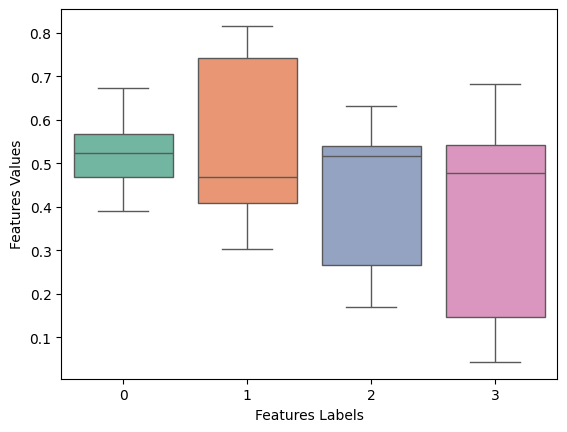

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(X_data_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

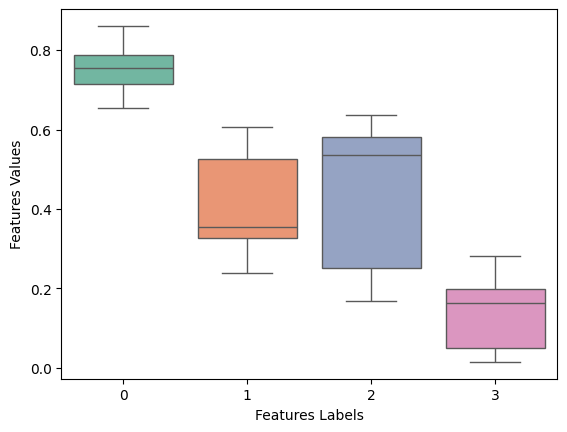

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(X_data_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_linha.svg')

## Treinamento

#### IQC AIL LINHA

In [ ]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 1



dic_training_params = {"max_iter": 200,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}
    
scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", np.max(scores_list))#max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", np.min(scores_list))#min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.0s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.37358494675575127), np.float64(0.28739607237477266), np.float64(0.36261576590404254)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.62      1.00      0.77         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.80        15
      macro avg       0.88      0.80      0.80        15
   weighted avg       0.88      0.80      0.80        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.3s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.36012716432050446), np.float64(0.29769613264125), np.float64(0.36190623096785746)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.87        15
   weighted avg       0.90      0.87      0.87        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   28.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #7
Mean negativities for all classes: [np.float64(0.3588252715063705), np.float64(0.29229822203407413), np.float64(0.3620264420338887)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.35838103099350754), np.float64(0.2965273082791945), np.float64(0.36451798656814344)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.35691634337922123), np.float64(0.2930882903694323), np.float64(0.36313200285660124)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.9s finished


#### IQC AIL COLUNA

In [ ]:
modelo = 'IQC_AIL_Coluna'
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])print_and_save_metrics(scores, f1scores, negativities_list, k_times_fold, 'IQC_AIL_Coluna', print_all=False)
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.3160829026169549), np.float64(0.1890194056208703), np.float64(0.19127214285082653)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.30612858429699963), np.float64(0.19148539277470744), np.float64(0.1868425884528807)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #7
Mean negativities for all classes: [np.float64(0.3041774658173706), np.float64(0.19181783028963784), np.float64(0.19363134419227374)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.2938597845386922), np.float64(0.19251057152638343), np.float64(0.1895272391321558)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.2942623343792416), np.float64(0.19914486948117613), np.float64(0.20126402738318577)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished


#### IQC LINHA

In [ ]:
modelo = 'IQC_Linha'
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list = np.copy(output_dict["negativities"])#negativities_list.append(output_dict["negativities"])
print_and_save_metrics(scores, f1scores, negativities_list, k_times_fold, 'IQC_Linha', print_all=False)

'''print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", np.max(scores_list))
print("Min Score dos K-Fold", np.min(scores_list))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])'''

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   16.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.3572027724570178), np.float64(0.29554767878557475), np.float64(0.3622713968020774)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.60      0.75         5
Iris-versicolor       0.56      1.00      0.71         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.73        15
      macro avg       0.85      0.73      0.74        15
   weighted avg       0.85      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.3443794103908088), np.float64(0.29083367657416814), np.float64(0.3619772258637342)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3588252715063705), np.float64(0.29229822203407413), np.float64(0.3620264420338887)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.35838103099350754), np.float64(0.2965273082791945), np.float64(0.36451798656814344)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.35691634337922123), np.float64(0.2930882903694323), np.float64(0.36313200285660124)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.4s finished


'print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))\nprint("Maior Score dos K-Fold", np.max(scores_list))\nprint("Min Score dos K-Fold", np.min(scores_list))\n\nprint("Media Score dos K-Fold", [np.mean(i) for i in scores_list])'

In [5]:
def print_and_save_metrics(scores, f1scores, negativities, k_times_fold, model, print_all=False):
    # Verificação de consistência
    if len(scores) != len(f1scores):
        raise ValueError("scores e f1scores devem ter o mesmo tamanho.")
    
    # Verifica se negativities tem o mesmo número de amostras que scores
    if negativities and len(negativities[0]) != len(scores):
        raise ValueError("Cada classe em negativities deve ter o mesmo número de elementos que scores.")

    # Cálculo das métricas básicas
    best_score = np.max(scores)
    best_f1 = np.max(f1scores)
    avg_score = np.mean(scores)
    avg_f1 = np.mean(f1scores)
    std_err_score = np.std(scores, ddof=1) / np.sqrt(len(scores))
    std_err_f1 = np.std(f1scores, ddof=1) / np.sqrt(len(f1scores))

    # Cálculo das estatísticas para cada classe em negativities (se existir)
    negativities_metrics = {}
    if negativities:
        negativities_metrics = {
            f"Negativity_Class_{i}": {
                "Mean": np.mean(values),
                "Std_Error": np.std(values, ddof=1) / np.sqrt(len(values))
            }
            for i, values in enumerate(negativities)
        }

    # Impressão dos resultados
    if print_all:
        print("Scores:", scores)
        print("F1-Scores:", f1scores)
        if negativities:
            for i, values in enumerate(negativities):
                print(f"Negativity Class {i}:", values)

    print(f"\nMétricas para {k_times_fold} folds (Modelo: {model}):")
    print(f"Melhor Score: {best_score:.4f}")
    print(f"Melhor F1-Score: {best_f1:.4f}")
    print(f"Score Médio: {avg_score:.4f} ± {std_err_score:.4f}")
    print(f"F1-Score Médio: {avg_f1:.4f} ± {std_err_f1:.4f}")
    
    for i, metrics in negativities_metrics.items():
        print(f"{i} - Média: {metrics['Mean']:.4f} ± {metrics['Std_Error']:.4f}")

    # Preparação do DataFrame para salvar
    data_to_save = {
        'Scores': scores,
        'F1_Scores': f1scores
    }
    
    # Adiciona negativities apenas se existir e for consistente
    if negativities and len(negativities[0]) == len(scores):
        for i, values in enumerate(negativities):
            data_to_save[f"Negativity_Class_{i}"] = values

    metrics_df = pd.DataFrame(data_to_save)
    
    # Nome do arquivo com data e modelo
    current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"metrics_results_{model}_{current_date}.csv"
    
    # Salvamento em CSV
    metrics_df.to_csv(filename, index=False)
    print(f"\nDados salvos em: {filename}")

print_and_save_metrics(scores, f1scores, negativities_list, k_times_fold, 'IQC_Linha', print_all=False)

ValueError: Cada classe em negativities deve ter o mesmo número de elementos que scores.

#### IQC COLUNA

In [ ]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.3160829026169549), np.float64(0.1890194056208703), np.float64(0.19127214285082653)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.30612858429699963), np.float64(0.19148539277470744), np.float64(0.1868425884528807)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #7
Mean negativities for all classes: [np.float64(0.3041774658173706), np.float64(0.19181783028963784), np.float64(0.19363134419227374)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   12.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.2938597845386922), np.float64(0.19251057152638343), np.float64(0.1895272391321558)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.2942623343792416), np.float64(0.19914486948117613), np.float64(0.20126402738318577)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   12.6s finished


#### IQC_PQ, NF2
A configuração do IQC_PQ precisa normalizar as linhas, apenas

In [ ]:
k_times_fold = 10
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
N_qubits_tgt = 2
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.6s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.47746755469743235), np.float64(0.5557455260277376), np.float64(0.5655543115375404)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.3s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.48038074964218364), np.float64(0.5500674674593811), np.float64(0.5616141137791445)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.3s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.47324371923541086), np.float64(0.546523274619502), np.float64(0.5571532693356402)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #9
Mean negativities for all classes: [np.float64(0.4590384421711497), np.float64(0.5413672203940076), np.float64(0.5541078605536434)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       0.75      0.60      0.67         5

       accuracy                           0.73        15
      macro avg       0.77      0.73      0.74        15
   weighted avg       0.77      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.9133333333333333 F1-Scores = 0.9122053872053872 Negativity = [np.float64(0.5329224640875702), np.float64(0.5306874436269031), np.float64(0.533756333279726)]
Media Score dos N K-Fold 0.9133333333333333
Maior Score dos K-Fold 0.9133333333333333
Min Score dos K-Fold 0.9133333333333333
Media Score dos K-Fold [np.float64(0.9133

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   17.3s finished


#### IQC_PQ, NF4, dic_classifier_params["normalize_axis"] = 1

In [ ]:
k_times_fold = 10
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
N_qubits_tgt = 4
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.6min finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.7030343323676613), np.float64(0.6800929260947368), np.float64(0.5938416842316412)]
                 precision    recall  f1-score   support

    Iris-setosa       0.40      0.40      0.40         5
Iris-versicolor       0.40      0.80      0.53         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.40        15
      macro avg       0.27      0.40      0.31        15
   weighted avg       0.27      0.40      0.31        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.6min finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.6934798858509983), np.float64(0.682076868907442), np.float64(0.5956371639752436)]
                 precision    recall  f1-score   support

    Iris-setosa       0.36      0.80      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.27        15
      macro avg       0.12      0.27      0.17        15
   weighted avg       0.12      0.27      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.6min finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.6937138808164178), np.float64(0.7111048202635865), np.float64(0.5981681029594281)]
                 precision    recall  f1-score   support

    Iris-setosa       0.17      0.20      0.18         5
Iris-versicolor       0.44      0.80      0.57         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.20      0.33      0.25        15
   weighted avg       0.20      0.33      0.25        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.7022784949017088), np.float64(0.6933483521513938), np.float64(0.6156918573997613)]
                 precision    recall  f1-score   support

    Iris-setosa       0.67      0.40      0.50         5
Iris-versicolor       0.42      1.00      0.59         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.47        15
      macro avg       0.36      0.47      0.36        15
   weighted avg       0.36      0.47      0.36        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.7min finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.7006587616442308), np.float64(0.6899467053582107), np.float64(0.6081101190774177)]
                 precision    recall  f1-score   support

    Iris-setosa       0.42      1.00      0.59         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.14      0.33      0.20        15
   weighted avg       0.14      0.33      0.20        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.3933333333333334 F1-Scores = 0.29263956087485504 Negativity = [np.float64(0.6589896475646798), np.float64(0.6570646395778946), np.float64(0.6559518624363799)]
Media Score dos N K-Fold 0.3933333333333334
Maior Score dos K-Fold 0.3933333333333334
Min Score dos K-Fold 0.3933333333333334
Media Score dos K-Fold [np.float64(0.39

#### IQC_PQ, NF4, dic_classifier_params["normalize_axis"] = 0

In [ ]:
k_times_fold = 10
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
N_qubits_tgt = 4
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.5min finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.7021452279809623), np.float64(0.5770969565292686), np.float64(0.5946733294601361)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.5min finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.6900245265166057), np.float64(0.5958587592139757), np.float64(0.6147224545535204)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  2.9min finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.7015838000362814), np.float64(0.5929173049559852), np.float64(0.6174691021575709)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  3.5min finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.7107801515048144), np.float64(0.5708518767001464), np.float64(0.5841133380340836)]
                 precision    recall  f1-score   support

    Iris-setosa       0.36      1.00      0.53         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.12      0.33      0.18        15
   weighted avg       0.12      0.33      0.18        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  3.8min finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.6904388232289386), np.float64(0.6036571824027663), np.float64(0.6176529535331181)]
                 precision    recall  f1-score   support

    Iris-setosa       0.36      1.00      0.53         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.12      0.33      0.18        15
   weighted avg       0.12      0.33      0.18        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.33333333333333337 F1-Scores = 0.17017543859649123 Negativity = [np.float64(0.624638504656789), np.float64(0.6335352467613673), np.float64(0.6112285991501899)]
Media Score dos N K-Fold 0.33333333333333337
Maior Score dos K-Fold 0.33333333333333337
Min Score dos K-Fold 0.33333333333333337
Media Score dos K-Fold [np.float64(0

#### IQCNDsE, dic_classifier_params["normalize_axis"] = 1

In [ ]:
k_times_fold = 10
classifier_function = iqcndsE_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.1088394242881518), np.float64(0.1302131922082281), np.float64(0.1728465233849629)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.09100025472328066), np.float64(0.1307974560609629), np.float64(0.17168235981826135)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.60      0.75         5
 Iris-virginica       0.71      1.00      0.83         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #7
Mean negativities for all classes: [np.float64(0.09838514618765035), np.float64(0.1363918917986528), np.float64(0.1665025074052372)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.08302728654319949), np.float64(0.1397270418975909), np.float64(0.1686820711433698)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.08629174340291633), np.float64(0.13674590738504863), np.float64(0.19179280742144797)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.1s finished


#### IQCNDsE, dic_classifier_params["normalize_axis"] = 0

In [ ]:
k_times_fold = 10
classifier_function = iqcndsE_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #0
Mean negativities for all classes: [np.float64(0.1088394242881518), np.float64(0.1302131922082281), np.float64(0.1728465233849629)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #1
Mean negativities for all classes: [np.float64(0.09100025472328066), np.float64(0.1307974560609629), np.float64(0.17168235981826135)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.60      0.75         5
 Iris-virginica       0.71      1.00      0.83         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.86        15
   weighted avg       0.90      0.87      0.86        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   18.4s finished


...

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #7
Mean negativities for all classes: [np.float64(0.09838514618765035), np.float64(0.1363918917986528), np.float64(0.1665025074052372)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   15.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.08302728654319949), np.float64(0.1397270418975909), np.float64(0.1686820711433698)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
K-Fold #9
Mean negativities for all classes: [np.float64(0.08629174340291633), np.float64(0.13674590738504863), np.float64(0.19179280742144797)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.7s finished


#### IQC_ANGLE

In [ ]:
k_times_fold = 10
classifier_function = iqc_angle_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1
dic_classifier_params["N_layers"] = 2
dic_classifier_params["iqc_angle"] = True
dic_classifier_params["qubits"] = [i for i in range(math.ceil(np.log2(N_FEATURES)+1))]

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False
}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_data, 
                y_data, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  2.1min finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.3425443396455689), np.float64(0.26387933739230063), np.float64(0.2673910977336471)]
                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.33      1.00      0.50         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  2.1min finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.3387557874641975), np.float64(0.2731446861894963), np.float64(0.2833569847474671)]
                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.33      1.00      0.50         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  2.3min finished


K-Fold #2
Mean negativities for all classes: [np.float64(0.3625394044113553), np.float64(0.2948235090479803), np.float64(0.299420458792576)]
                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.33      1.00      0.50         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


KeyboardInterrupt: 

#### Rascunho

In [42]:
from qiskit.quantum_info import Operator, partial_trace
from qiskit import QuantumCircuit

def build_circuit_matrix(x_vals, N_layers=2):
    """
    Constrói numericamente a matriz do circuito com R_x (em todos os qubits exceto o primeiro)
    e CNOTs em cascata.
    
    Args:
        x_vals (list or np.array): lista de parâmetros [x_0, x_1, ..., x_{N_features}]
    
    Returns:
        np.array: matriz unitaría do circuito como um np.array complexo (2^N x 2^N)
    """
    N_features = len(x_vals)
    N_qubits = N_features + 1  # inclui o qubit extra (tipicamente ancilla ou controle)

    qc = QuantumCircuit(N_qubits)

    qc.h(0)  # Aplicar Hadamard no qubit 0
    for _ in range(N_layers):
        # Aplicar R_x(x_i) para qubits de 1 até N_features
        for i in range(1, N_qubits):
            qc.rx(x_vals[i-1], i)

        # Aplicar CNOTs em cascata: q1→q2, q2→q3, q3→q4, ..., até o penúltimo
        for i in range(1, N_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.barrier()
        # Converter o circuito em matriz unitára
    display(qc.draw('mpl'))  # Desenhar o circuito para visualização (opcional)
    U = Operator(qc).data
    return U

NF=5
N_qubits=NF+1  # Número de qubits do circuito
qubits=[i for i in range(N_qubits)]

x = np.random.rand(NF)  # Exemplo de vetor de parâmetros
w = np.random.rand(2**(NF))  # Exemplo de vetor de pesos
M=build_angle_matrix(np.pi*x, N_qubits, N_layers=2)

sigmaX = np.array([[0,1], [1,0]])
sigmaY = np.array([[0,-1j], [1j,0]])
sigmaZ = np.array([[1,0], [0,-1]])
sigmaQ = sigmaX + sigmaY + sigmaZ

# Verifica se precisa ajustar sigmaE
sigmaE = np.diag(w)
"""# Calcula o operador unitário U
dim_circuit = 2 ** (N_qubits - 1)
dim_sigmaE = sigmaE.shape[0]
sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)"""

psi = Statevector.from_int(0, dims=2**N_qubits)
rho = DensityMatrix(psi.evolve(M))  # Evolução do estado inicial com a matriz M
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

rho_final = rho.evolve(U)  # Equivalente a U ρ U^†
rho_res = partial_trace(rho_final, qubits[1:])
display("Rho:", rho_res.draw('text'))
print("Pureza(rho_res):", (rho_res.purity()))
#rho_res.draw('city')


'Rho:'

[[0.5       -2.78716191e-18j,0.39527376+3.85740788e-02j],
 [0.39527376-3.85740788e-02j,0.5       -9.55114351e-18j]]

Pureza(rho_res): (0.8154586153055228-1.214306433183765e-17j)


In [10]:
def iqc_angle_classifier(vector_x, 
                   vector_ws,
                   normalize_x=False, 
                   normalize_w=False, 
                   dic_classifier_params={},
                   N_qubits=None,
                   N_qubits_tgt=None,
                   N_layers=None):
    # IQC-Angle Embedding
    """
        Applies the a modified version of ICQ classifier using only the math behind the Quantum Classifier described in Interactive Quantum Classifier Inspired by Quantum Open System Theory article. 
        
        It differs from the original ICQ by adding a new component to Sigma Q: sigmaH, which corresponds to a Haddamard's gate. Another difference is that we load the input in the environment instead of having a combination of weights and inputs in sigmaE.

        After doing so, it gets the result of Equation #20 and returns Z as the predicted class and the probability of being the class 1.
        
        Works only for binary classifications, therefore, if the probability of class 0 is needed, it can be 1 - probability of being class 1.

        There are a few possible keys for the dic_classifier_params:
        - sigma_q_params (array) = weights used for calculating sigma_q
        - use_polar_coordinates_on_sigma_q (boolean) = whether to calculate sigma_q using polar coordinates or weighted sum
        - load_inputvector_env_state (boolean) = whether to load input vector on the environment state (True) or on sigma_e (False)
        - operation_for_sigma_e (string) = which operation will be used to combine weights and X for load_inputvector_env_state = False. For now, only "sum" and "mul" are available.
        - calculate_negativity (boolean) = enables the negativity calculation. Check https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics). Uses Toqito implementation: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
        - ending_hadamard_gate (int) =  adds a Hadamard gate after the U operator
        - use_exponential_on_input (boolean) = does the Euler exponential on the input data after normalizing (if applied)

        To have the original ICQ Classifier, you can have:
        normalize_x = False
        normalize_w = False
        dic_classifier_params["load_inputvector_env_state"] = False
        dic_classifier_params["sigma_q_params"] = [1, 1, 1, 0]

        returns (z, p_cog_new_11_2, output_dict)

        output_dict contains:
        - U_operators = list of used U_operators
        - negativity = negativity associated with that entry
        - entropy = entropy associated with that entry
    """
    
    N = len(vector_x)
    if "sigma_q_params" in dic_classifier_params:
        sigma_q_params = dic_classifier_params["sigma_q_params"]
    if "use_polar_coordinates_on_sigma_q" in dic_classifier_params:
        use_polar_coordinates_on_sigma_q = dic_classifier_params["use_polar_coordinates_on_sigma_q"]
    

    if normalize_x:
        vector_x = normalize(vector_x)
    if "use_exponential_on_input" in dic_classifier_params and dic_classifier_params["use_exponential_on_input"]:
        vector_x = np.exp(vector_x)
    
    if (use_polar_coordinates_on_sigma_q):
        # Eq #16, but using polar coordinates so |sigmaQ| gets to be 1
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        # Eq #16
        sigmaQ = get_weighted_sigmaQ(sigma_q_params)

    # We want to have multiple environments, thus we need to have a list of weights for each of them
    if not(isinstance(vector_ws, (list, np.ndarray)) and all(isinstance(item, (list, np.ndarray)) for item in vector_ws)):
        vector_ws = np.array(vector_ws, dtype=complex)
    
    '''
    # Eq 25
    p_env = np.ones((N,1))/np.sqrt(N)
    p_env = get_p(p_env)

    # Our first p_cog will be the original one, but will change overtime
    p_cog = np.ones((2,1)) / np.sqrt(2) 
    # Eq #18
    p_cog = get_p(p_cog)

    # We'll update the p_cog for every env we have
    p_cog_new = p_cog
    '''
    N_qubits = dic_classifier_params["N_qubits"]
    N_qubits_tgt = dic_classifier_params["N_qubits_tgt"]
    qubits = dic_classifier_params["qubits"]
    N_layers= dic_classifier_params["N_layers"]
    
    U_operators = []
    for vector_w in vector_ws:
        if normalize_w:
            vector_w = normalize(vector_w)
        # We don't want to mix both proposed approach and multiple environments, as it'll be confusing
        if len(vector_ws) > 1:
            raise Exception("Not possible to load weights on env and have multiple envs!")

        sigmaE = np.diag(vector_w)
        U_operator = get_U_operator(sigmaQ, sigmaE)
        U_operators.append(U_operator)

        print("Shape of sigmaQ:", sigmaQ.shape)
        print("Shape of sigmaE:", sigmaE.shape)
        print("Shape of U:", U_operator.shape)

        # Eq #19 applied on a Quantum state equivalent of Hadamard(|00...0>) = 1/sqrt(N) * (|00...0> + ... + |11...1>)
        # We can either have Hadamard applied to each instance attribute...
        vector_x_normalized = vector_x / (np.linalg.norm(vector_x) + 1e-16) 
        psi = Statevector.from_int(0, dims=2**N_qubits)
        M = build_angle_matrix(np.pi*vector_x_normalized, N_qubits, N_layers=N_layers)
        print("Shape of M:", M.shape)
        psi = psi.evolve(M)  # Equivalent to M * psi
        p = DensityMatrix(psi.evolve(M))  # Density matrix of the state after evolution M
        print("Shape of p:", p.data.shape)
        p_out = p.evolve(U_operator)  # Equivalente a U ρ U^†
        p_cog_new = partial_trace(p_out, qubits[1:]).data
    # As the result is a diagonal matrix, the probability of being class 0 will be on position 0,0
    p_cog_new_00_2 = p_cog_new[0,0]

    # ... and the probability of being class 1 will be on position 1,1
    p_cog_new_11_2 = p_cog_new[1,1]
    if (p_cog_new_00_2 >= p_cog_new_11_2):
        z = 0
    else:
        z = 1

    output_dict = {}
    output_dict["U_operators"] = U_operators
    
    if "calculate_negativity" in dic_classifier_params and dic_classifier_params["calculate_negativity"]:
        output_dict["negativity"] = get_negativity(p_out, [2, N])

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/evolution_calc.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/ins_and_outs.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "sigmaQ = " + generate_output_matrix_string(sigmaQ) + ";\n"\
        #                     + "sigmaE = " + generate_output_matrix_string(sigmaE) + ";\n"\
        #                     + "p_cog = " + generate_output_matrix_string(p_cog) + ";\n"\
        #                     + "p_env = " + generate_output_matrix_string(p_env) + ";\n"\
        #                     + "p_cog_env = " + generate_output_matrix_string(p_cog_env) + ";\n"\
        #                     + "p_out = " + generate_output_matrix_string(p_out) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/negativity.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n - Negativity = " + str(output_dict["negativity"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

    if "calculate_entropy" in dic_classifier_params and dic_classifier_params["calculate_entropy"]:
        output_dict["entropy"] = get_entropy(p_out)
        
        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/entropy.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n -Entropy = " + str(output_dict["entropy"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")
     
    return z, p_cog_new_11_2, output_dict

In [4]:
NF=10
x = np.random.rand(NF)  # Exemplo de vetor de parâmetros
NQ = math.ceil(np.log2(NF)+1)
w = np.random.rand(2**(NQ-1))  # Exemplo de vetor de pesos

def build_angle_matrix(x_vals, N_qubits, N_layers=2):
    """
    Numerically constructs the circuit matrix with R_x gates (on all qubits except the first)
    and cascaded CNOTs. This function builds an unitary matrix that acts on Hilberts composed 
    state space.
    
    Args:
        x_vals (list or np.array): List of parameters [x_0, x_1, ..., x_{N_features}]
    
    Returns:
        np.array: Unitary matrix of the circuit as a complex np.array (2^N x 2^N)
    """
    
    qc = QuantumCircuit(N_qubits)

    qc.h(0)  # Apply Hadamard at q 0
    for _ in range(N_layers):
        # Apply R_x(x_i) for qubits from 1 to N_features
        for i in range(1, N_qubits):
            qc.rx(x_vals[i-1], i)

        # Apply cascaded CNOTs: q1→q2, q2→q3, q3→q4, ..., till qN-1→qN
        for i in range(1, N_qubits - 1):
            qc.cx(i, i + 1)
        
        # Convert circuit to unitary matrix
    M = Operator(qc).data
    return M

dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = NQ #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1
dic_classifier_params["N_layers"] = 2

dic_classifier_params["qubits"] = [i for i in range(NQ)]

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False,
"iqc_angle":True}

iqc_angle_classifier(x, 
                   [w],
                   normalize_x=False, 
                   normalize_w=False, 
                   dic_classifier_params=dic_classifier_params,
                   N_qubits=NQ,
                   N_qubits_tgt=1,
                   N_layers=2)

Shape of sigmaQ: (2, 2)
Shape of sigmaE: (16, 16)
Shape of U: (32, 32)
Shape of p: (32, 32)


(0,
 np.complex128(0j),
 {'U_operators': [matrix([[ 0.74964318+0.38211478j,  0.        +0.j        ,
             0.        +0.j        , ...,  0.        +0.j        ,
             0.        +0.j        ,  0.        +0.j        ],
           [ 0.        +0.j        , -0.10372727+0.57423591j,
             0.        +0.j        , ...,  0.        +0.j        ,
             0.        +0.j        ,  0.        +0.j        ],
           [ 0.        +0.j        ,  0.        +0.j        ,
             0.84137749+0.31202773j, ...,  0.        +0.j        ,
             0.        +0.j        ,  0.        +0.j        ],
           ...,
           [ 0.        +0.j        ,  0.        +0.j        ,
             0.        +0.j        , ...,  0.99554822-0.05441735j,
             0.        +0.j        ,  0.        +0.j        ],
           [ 0.        +0.j        ,  0.        +0.j        ,
             0.        +0.j        , ...,  0.        +0.j        ,
             0.96759592-0.1457831j ,  0.        

In [5]:
from sympy import symbols, Matrix, eye, zeros
from numpy import kron
from sympy.physics.quantum import TensorProduct
from sympy import pprint

# Definir operadores básicos
I = eye(2)  # Identidade
X = Matrix([[0, 1], [1, 0]])  # Pauli-X
P0 = Matrix([[1, 0], [0, 0]])  # |0⟩⟨0|
P1 = Matrix([[0, 0], [0, 1]])   # |1⟩⟨1|

# Construir a matriz CNOT controlada por |0⟩ (qubit 2 → qubit 5)
termo_0 = TensorProduct(P0, I, I, I, X)  # Se qubit 2 = |0⟩, aplica X no qubit 5
termo_1 = TensorProduct(P1, I, I, I, I)  # Se qubit 2 = |1⟩, aplica I no qubit 5
CNOT_simbolica = termo_0 + termo_1

# Mostrar a matriz
print("Matriz CNOT controlada por |0⟩ (qubit 2 → qubit 5):")
pprint(CNOT_simbolica)

Matriz CNOT controlada por |0⟩ (qubit 2 → qubit 5):
⎡0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                                              ↪
⎢1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                                              ↪
⎢0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                                              ↪
⎢0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                                              ↪
⎢0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                                              ↪
⎢0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  ↪
⎢                                                        